In [ ]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for as


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('../Data/creditcard.csv')

In [19]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst look:")
df.head()

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First look:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [20]:
df.shape

(284807, 31)

In [22]:
df.columns
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [23]:
print("Fraud Distribution:")
print(df['Class'].value_counts())
print("\n")


Fraud Distribution:
Class
0    284315
1       492
Name: count, dtype: int64




In [31]:
fraud_pct = df['Class'].value_counts(normalize=True) * 100
print("Percentage:")
print(fraud_pct.round(2))

Percentage:
Class
0    99.83
1     0.17
Name: proportion, dtype: float64


In [36]:
print("\nMissing Values:")
print(df.isnull().sum().sum())



Missing Values:
0


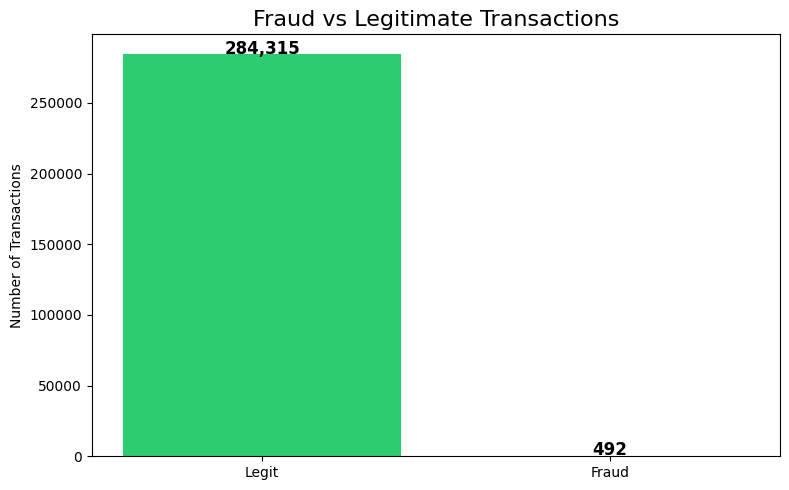


Total Transactions: 284,807
Fraud Cases: 492
Legit Cases: 284,315


In [39]:
fraud_counts = df['Class'].value_counts()
labels = ['Legit', 'Fraud']
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(8,5))
plt.bar(labels, fraud_counts, color=colors)
plt.title('Fraud vs Legitimate Transactions', fontsize=16)
plt.ylabel('Number of Transactions')

# Add numbers on top of bars
for i, v in enumerate(fraud_counts):
    plt.text(i, v + 100, f'{v:,}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/fraud_vs_legit.png')
plt.show()

print(f"\nTotal Transactions: {len(df):,}")
print(f"Fraud Cases: {fraud_counts[1]:,}")
print(f"Legit Cases: {fraud_counts[0]:,}")

In [40]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print("=== FRAUD TRANSACTIONS ===")
print(f"Average fraud amount: ${fraud['Amount'].mean():.2f}")
print(f"Max fraud amount:     ${fraud['Amount'].max():.2f}")
print(f"Min fraud amount:     ${fraud['Amount'].min():.2f}")

print("\n=== LEGIT TRANSACTIONS ===")
print(f"Average legit amount: ${legit['Amount'].mean():.2f}")
print(f"Max legit amount:     ${legit['Amount'].max():.2f}")


=== FRAUD TRANSACTIONS ===
Average fraud amount: $122.21
Max fraud amount:     $2125.87
Min fraud amount:     $0.00

=== LEGIT TRANSACTIONS ===
Average legit amount: $88.29
Max legit amount:     $25691.16


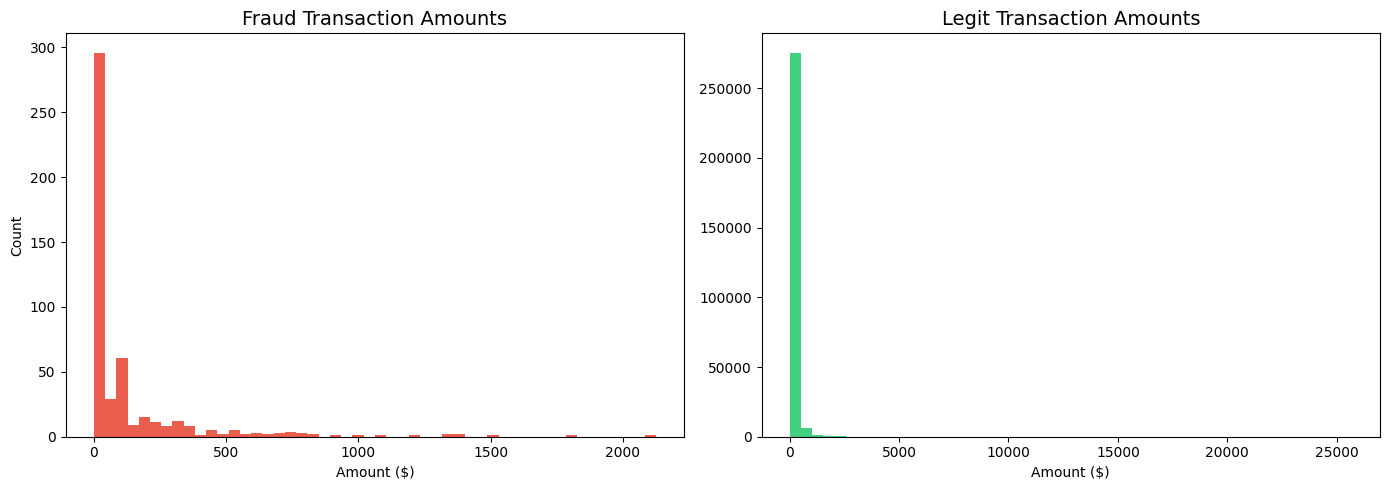

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(fraud['Amount'], bins=50, color='#e74c3c', alpha=0.9)
ax1.set_title('Fraud Transaction Amounts', fontsize=14)
ax1.set_xlabel('Amount ($)')
ax1.set_ylabel('Count')
ax2.hist(legit['Amount'], bins=50, color='#2ecc71', alpha=0.9)
ax2.set_title('Legit Transaction Amounts', fontsize=14)
ax2.set_xlabel('Amount ($)')

plt.tight_layout()
plt.savefig('../data/amount_distribution.png')
plt.show()

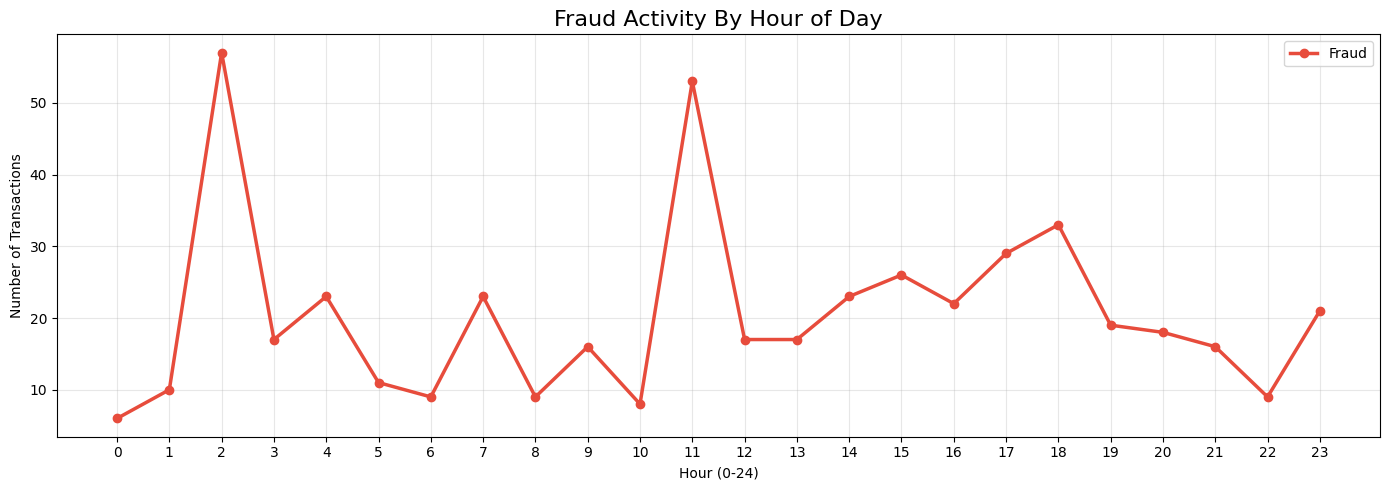

Peak fraud hour: 2


In [45]:
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()
legit_by_hour = df[df['Class'] == 0].groupby('Hour').size()

plt.figure(figsize=(14, 5))
plt.plot(fraud_by_hour.index, fraud_by_hour.values, 
         color='#e74c3c', linewidth=2.5, marker='o', label='Fraud')
plt.title('Fraud Activity By Hour of Day', fontsize=16)
plt.xlabel('Hour (0-24)')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../data/fraud_by_hour.png')
plt.show()

print("Peak fraud hour:", fraud_by_hour.idxmax())

In [47]:
df['Hour'] = (df['Time'] / 3600).astype(int) % 24
df['Transaction_Type'] = df['Class'].map({0: 'Legit', 1: 'Fraud'})
df.to_csv('../Data/creditcard_clean.csv', index=False)

print("✅ Exported: creditcard_clean.csv")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

✅ Exported: creditcard_clean.csv
Rows: 284,807
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Hour', 'Transaction_Type']
